In [1]:
import numpy as np
import matplotlib.pyplot as plt
from core.greeks import delta
from core.pnl_attribution import hedge_pnl_error

In [2]:
S=100 
K=100
r=0.05
q=0.02
sigma=0.20
T=1.0
rho_true = 0.15
rho_wrong = [0.00, 0.05, 0.10]


## Hedge error across spot levels

The error peaks at 38 euros per share when repo is completely ignored, and at 25 euros 
when underestimated by 10 points. The gap is largest around the ATM level where delta 
is most sensitive to small changes in the forward.

On a position of 10,000 shares that is between 100,000 and 380,000 euros of mishedge 
depending on how wrong your repo estimate is. That number accumulates silently through 
every daily rebalancing.

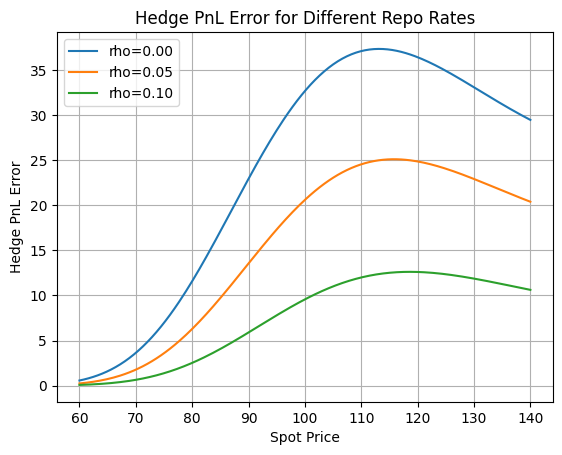

In [3]:
S = np.linspace(60, 140, 200)

for rho in rho_wrong:
    pnl_error = hedge_pnl_error(S, K, r, q, rho_true, rho, T, sigma, 'call')
    plt.plot(S, pnl_error, label=f"rho={rho:.2f}")
plt.title("Hedge PnL Error for Different Repo Rates")
plt.xlabel("Spot Price")
plt.ylabel("Hedge PnL Error")
plt.legend()
plt.grid()
plt.show()

## Cumulative hedge error over time

The error does not accumulate in one direction. It oscillates depending on whether the 
spot is moving up or down relative to the wrong hedge. When the spot rises and the trader 
is under-hedged, the error grows. When it falls, part of that error is recovered.

What matters is the amplitude of the swings. A trader using zero repo on a position with 
a true borrow of 15% will see larger oscillations than one who underestimates by only 5 
points. The further the repo estimate is from reality, the more the hedge drifts from the 
correct position and the more exposed the book becomes to directional moves.

In [4]:
np.random.seed(42)
N = 252
dt = 1/252

S_path = np.zeros(N)
S_path[0] = 100

for t in range(1, N):
    Z = np.random.normal()
    S_path[t] = S_path[t-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)



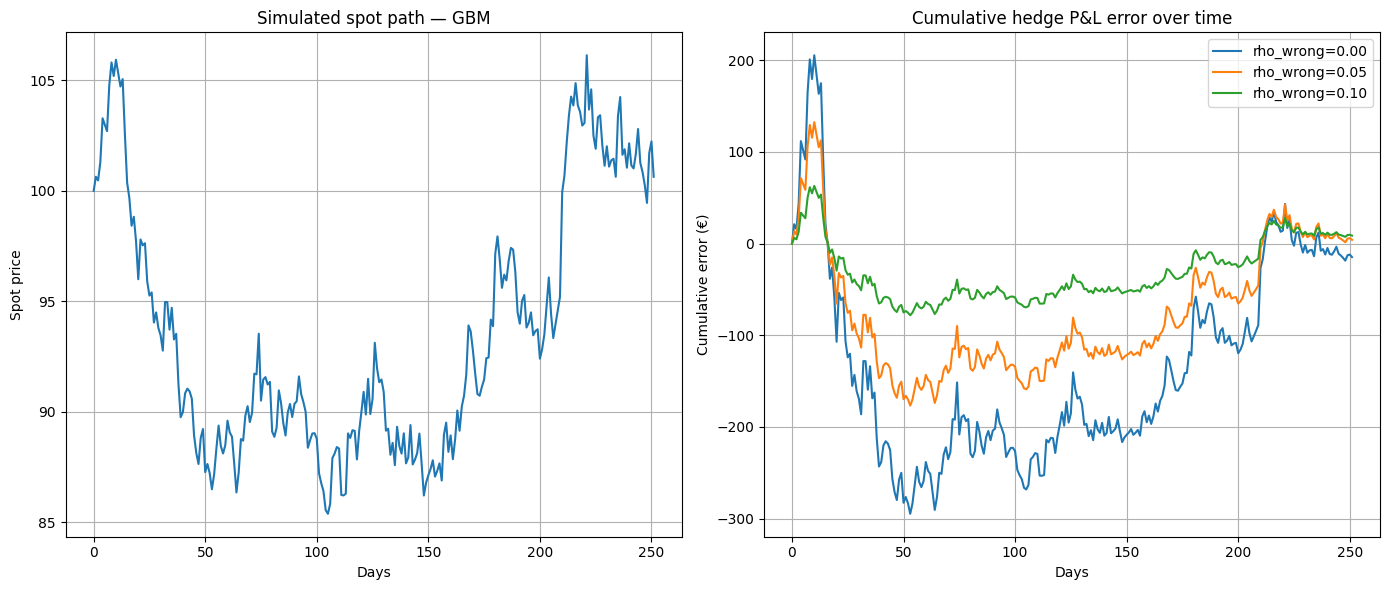

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(S_path)
ax1.set_title("Simulated spot path — GBM")
ax1.set_xlabel("Days")
ax1.set_ylabel("Spot price")
ax1.grid(True)

for rho_w in rho_wrong:
    cumulative_error = np.zeros(N)
    for t in range(1, N):
        T_remaining = (N - t) / 252
        if T_remaining <= 0:
            break
        error = hedge_pnl_error(S_path[t], K, r, q, rho_true, rho_w, T_remaining, sigma, 'call')
        move = S_path[t] - S_path[t-1]
        cumulative_error[t] = cumulative_error[t-1] + error * move
    ax2.plot(cumulative_error, label=f"rho_wrong={rho_w:.2f}")

ax2.set_title("Cumulative hedge P&L error over time")
ax2.set_xlabel("Days")
ax2.set_ylabel("Cumulative error (€)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()